C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_29064\1758252679.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  coolwarm_r = cm.get_cmap("coolwarm_r")
C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_29064\1758252679.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  coolwarm   = cm.get_cmap("coolwarm")
C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_29064\1758252679.py:116: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding="utf-8-sig")


P period: 2021-06-01 00:00:00 to 2023-10-30 00:00:00
P max daily (mm): 36.6
P total (mm): 1580.3


C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_29064\1758252679.py:129: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return df.set_index("datetime")[["Snow depth [mm]"]].resample("H").mean()
C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_29064\1758252679.py:143: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return df.set_index("datetime")["Ilman lämpötila [°C]"].resample("H").mean()
C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_29064\1758252679.py:196: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  Ts = Ts.resample("H").mean().loc[start_date:end_date]


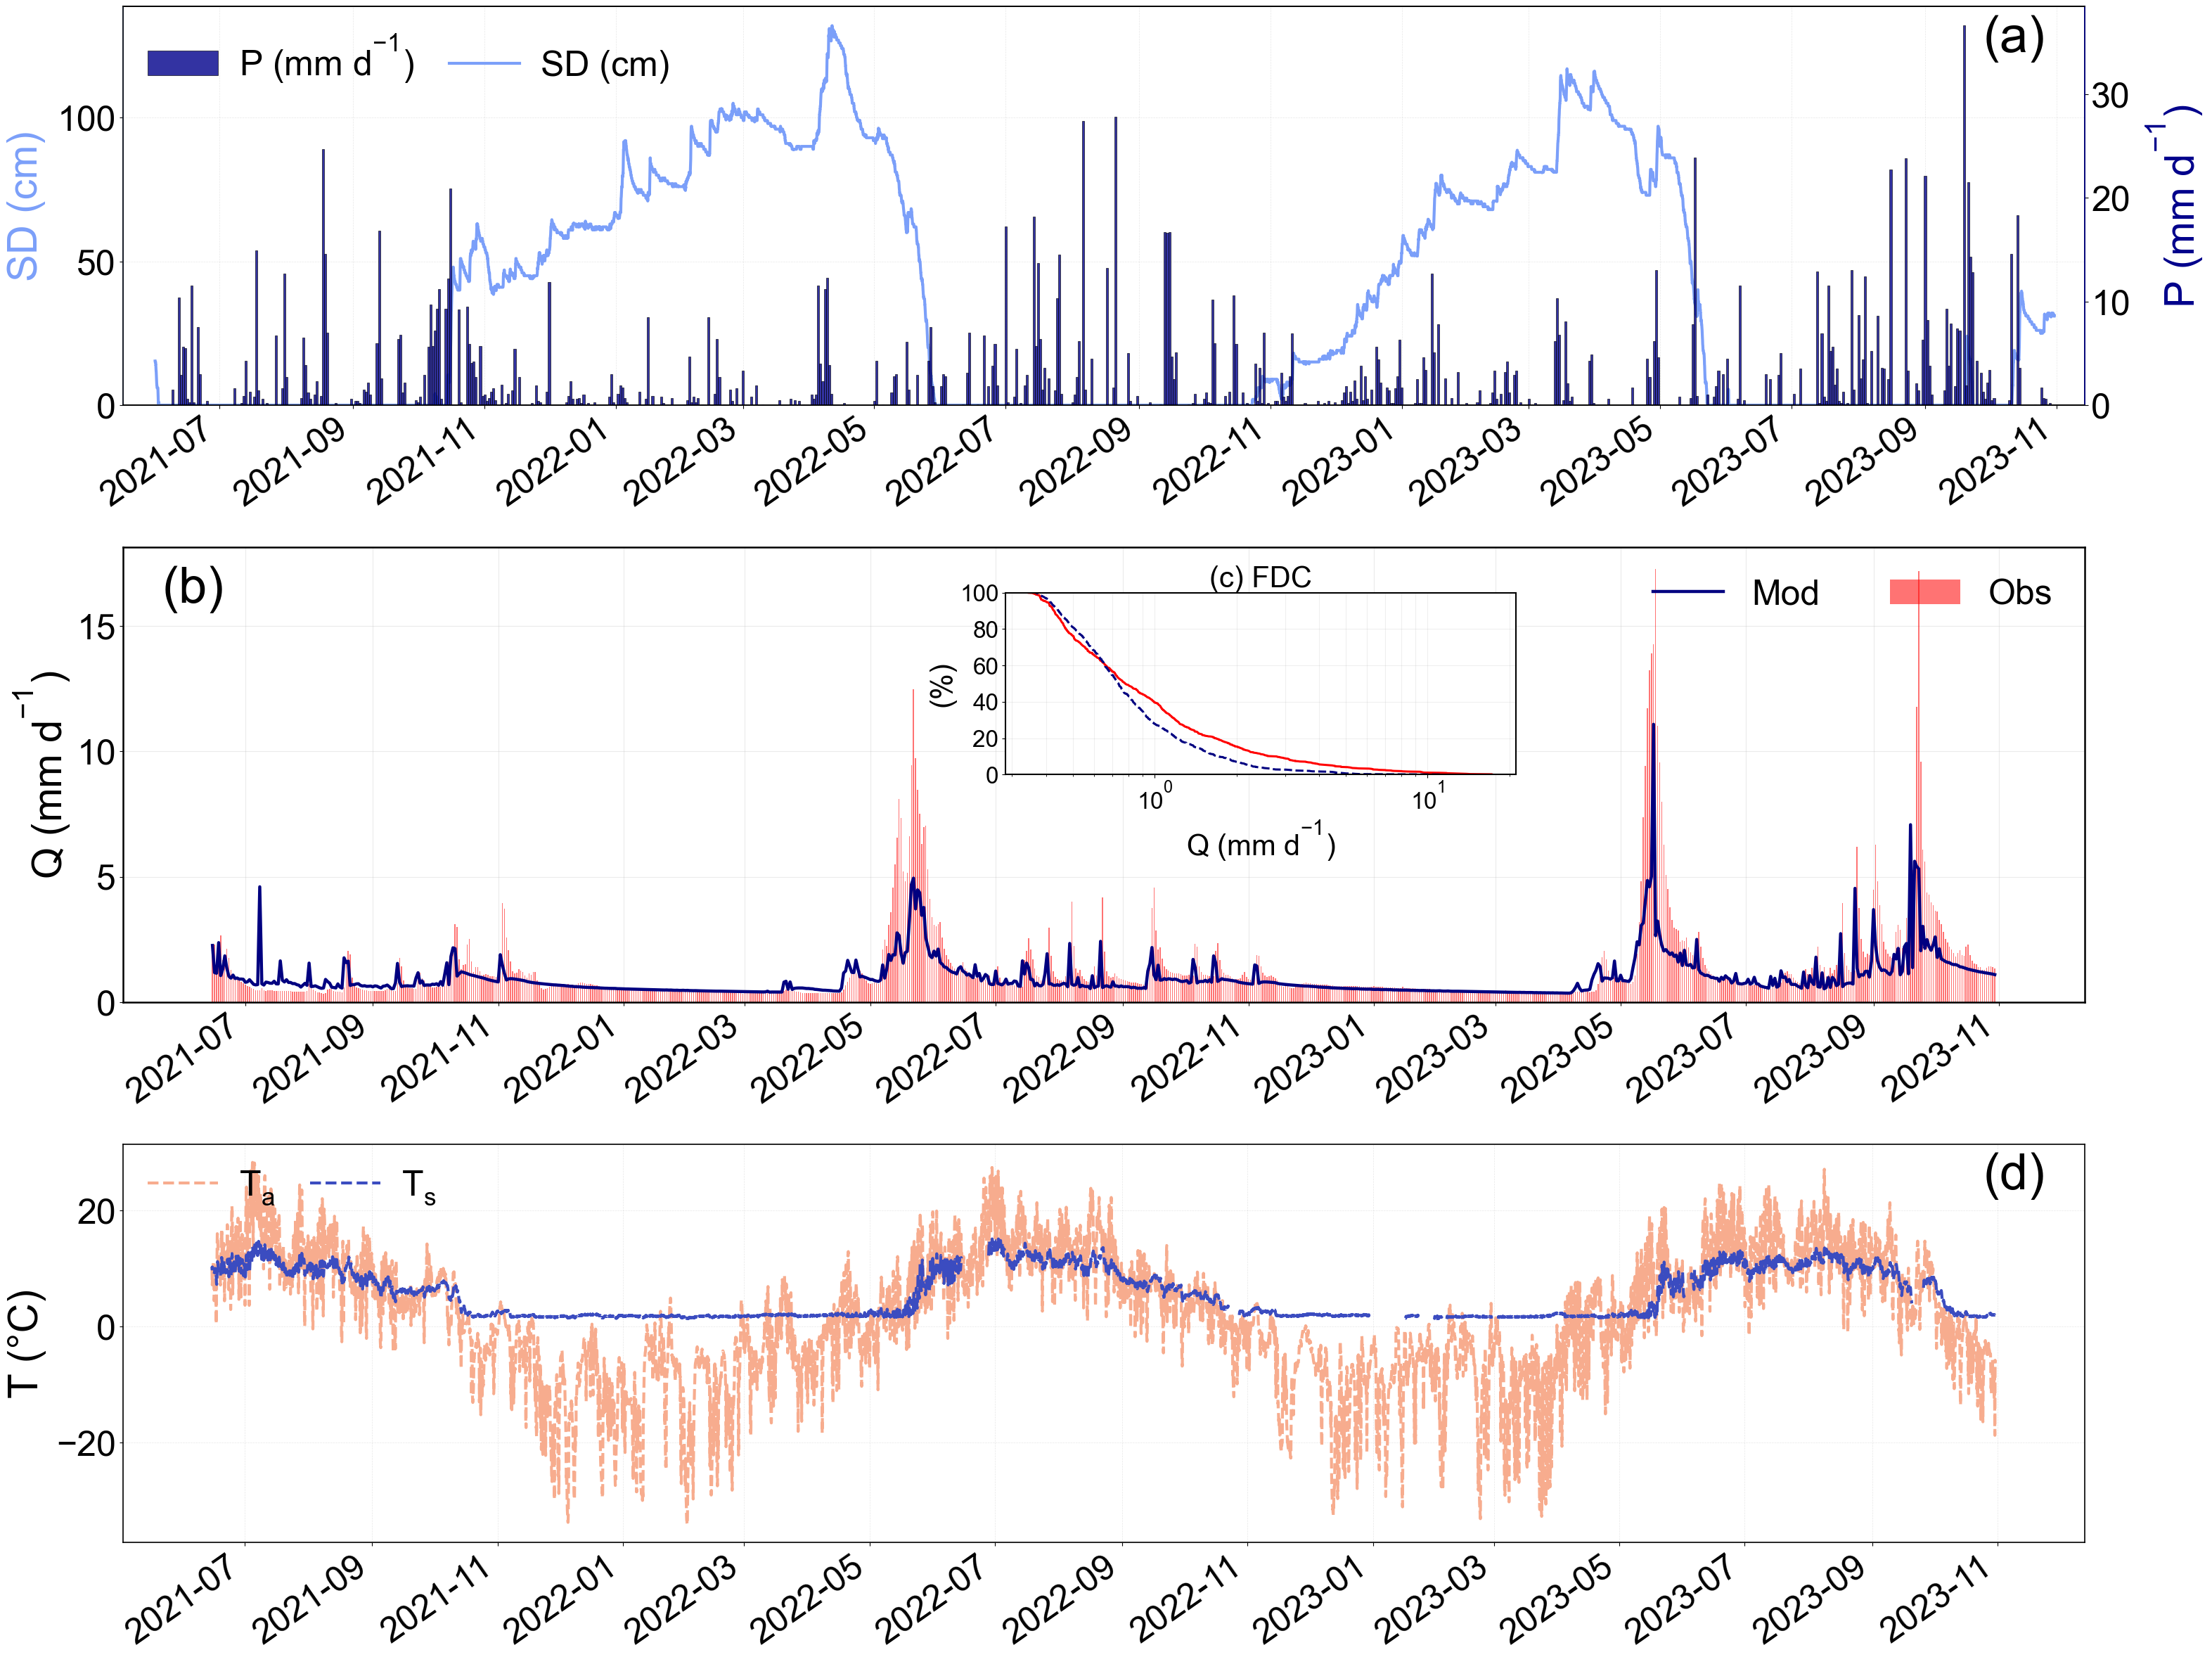

In [ ]:


import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm


BASE_DATA_DIR = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Dataset - All"

# Removed PRECIP_FILE2 usage completely
FORCING_CSV = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Input\spafhy_input\pallas\forcing\FORCING.csv"

RUNOFF_FILE  = rf"{BASE_DATA_DIR}\Discharge - CSV\30 min interval Discharge\30 min interval Discharge.New csv file.csv"
SNOW_FILE    = rf"{BASE_DATA_DIR}\snow\Snow depth kittila.csv"
METEO_FILE2  = rf"{BASE_DATA_DIR}\AIR - CSV - FIN\Kittilä Lompolonvuoma_ 15.6.2021 - 30.9.2024_5e96c0a2-f753-48fd-a243-b964825ff831.csv"
WATERTEMP_NC = rf"{BASE_DATA_DIR}\pallas_dts_data_f_6.nc"

MODEL_OUTPUT = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Input\spafhy_input\pallas\results\pallas_analysis_2_2D_202602181223\202602181222_inflow_to_ditch_pos.nc"

# Time window
START_DATE = "2021-06-01"
END_DATE   = "2023-10-30"
TIME_SLICE = slice(START_DATE, END_DATE)


SAVE_FIG = None  


plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.linewidth"] = 1.2

plt.rcParams["axes.labelsize"] = 42
plt.rcParams["xtick.labelsize"] = 36
plt.rcParams["ytick.labelsize"] = 36
plt.rcParams["legend.fontsize"] = 36

plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Arial"


coolwarm_r = cm.get_cmap("coolwarm_r")
coolwarm   = cm.get_cmap("coolwarm")

precip_color = "darkblue"
sd_color     = coolwarm_r(0.8)

air_color    = coolwarm(0.7)
water_color  = coolwarm(0.0)

OBS_COLOR = "red"
SIM_COLOR = "navy"


def read_precip_from_forcing_csv(forcing_csv_path, time_slice):
    """
    Reads daily precipitation from SpaFHy forcing CSV.
    File is semicolon separated.
    Expected:
      - column: time (YYYY-MM-DD)
      - column: rainfall (mm d-1), daily timestep
    """
    df = pd.read_csv(forcing_csv_path, sep=";", engine="python")
    df.columns = df.columns.str.strip()

    if "time" not in df.columns:
        raise ValueError(f"'time' column not found in forcing CSV. Columns: {df.columns.tolist()}")
    if "rainfall" not in df.columns:
        raise ValueError(f"'rainfall' column not found in forcing CSV. Columns: {df.columns.tolist()}")

    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.dropna(subset=["time"]).set_index("time").sort_index()

    # Normalize to midnight (important for clean alignment with daily series)
    df.index = df.index.normalize()

    P = pd.to_numeric(df["rainfall"], errors="coerce").fillna(0.0)
    P = P.loc[time_slice]
    return P

def read_runoff_csv(file_path):
    df = pd.read_csv(file_path, parse_dates=["datetime"]).set_index("datetime").sort_index()
    df = df.rename(columns={"Discharge": "Q_m3s"})
    return df

def read_snow_csv(file_path):
    df = pd.read_csv(file_path, encoding="utf-8-sig")
    df.columns = df.columns.str.strip()
    df["datetime"] = pd.to_datetime(
        df["Year"].astype(str)
        + "-"
        + df["Month"].astype(str)
        + "-"
        + df["Day"].astype(str)
        + " "
        + df["Time [Local time]"]
    )
    df["Snow depth [cm]"] = pd.to_numeric(df["Snow depth [cm]"], errors="coerce").clip(lower=0)
    df["Snow depth [mm]"] = df["Snow depth [cm]"] * 10.0
    return df.set_index("datetime")[["Snow depth [mm]"]].resample("H").mean()

def read_airtemp_csv_fmi(file_path):
    df = pd.read_csv(file_path)
    df["datetime"] = pd.to_datetime(
        df["Vuosi"].astype(str)
        + "-"
        + df["Kuukausi"].astype(str)
        + "-"
        + df["Päivä"].astype(str)
        + " "
        + df["Aika [Paikallinen aika]"]
    )
    df["Ilman lämpötila [°C]"] = pd.to_numeric(df["Ilman lämpötila [°C]"], errors="coerce")
    return df.set_index("datetime")["Ilman lämpötila [°C]"].resample("H").mean()

def compute_fdc_exceedance_percent(q_series):
    q = np.asarray(q_series, dtype=float)
    q = q[np.isfinite(q)]
    q = q[q >= 0]
    q_sorted = np.sort(q)[::-1]
    n = len(q_sorted)
    if n == 0:
        return np.array([]), np.array([])
    m = np.arange(1, n + 1)
    p_exc = 100.0 * m / (n + 1.0)
    return p_exc, q_sorted

def thicken_spines(ax, lw=1.8):
    for s in ax.spines.values():
        s.set_linewidth(lw)



# MAIN PLOTTING

def plot_all_four_panels(
    forcing_csv,
    runoff_file,
    snow_file,
    meteo_file2,
    watertemp_file,
    model_output_nc,
    time_slice,
    start_date,
    end_date,
    save_fp=None,
):
    # -----------------------------
    # LOAD CLIMATE DATA
    # -----------------------------
    # P from forcing CSV (daily, mm d-1)
    P = read_precip_from_forcing_csv(forcing_csv, time_slice=time_slice)
    print("P period:", P.index.min(), "to", P.index.max())
    print("P max daily (mm):", float(P.max()))
    print("P total (mm):", float(P.sum()))

    snow = read_snow_csv(snow_file).loc[time_slice]
    SD_cm = (snow["Snow depth [mm]"] * 0.1).dropna()

    Ta = read_airtemp_csv_fmi(meteo_file2).loc[start_date:end_date]

    dsT = xr.open_dataset(watertemp_file, engine="netcdf4")
    temp_var = [v for v in dsT.data_vars if "time" in dsT[v].dims][0]
    Ts = dsT[temp_var].to_pandas()
    if isinstance(Ts, pd.DataFrame):
        Ts = Ts.mean(axis=1)
    Ts = Ts.resample("H").mean().loc[start_date:end_date]

    # LOAD Q OBS + MODEL
   
    q_obs_30min = read_runoff_csv(runoff_file)
    q_obs_daily_m3s = q_obs_30min["Q_m3s"].resample("D").mean().dropna()
    q_obs_daily_m3s.index = pd.to_datetime(q_obs_daily_m3s.index).normalize()

    dsQ = xr.open_dataset(model_output_nc, engine="netcdf4")
    t_ds = pd.to_datetime(dsQ["time"].values).normalize()

    CELLSIZE = 16
    spatial_dims = [d for d in dsQ["bucket_surface_runoff"].dims if d != "time"]
    cmask_bool = xr.apply_ufunc(np.isfinite, dsQ["bucket_surface_runoff"].isel(time=0))
    n_cells = int(cmask_bool.sum().values)
    A_m2 = n_cells * CELLSIZE * CELLSIZE

    Qsim_xr = (dsQ["bucket_surface_runoff"] + dsQ["deep_netflow_to_ditch"]).where(cmask_bool).mean(dim=spatial_dims)
    Qsim_mm_d = pd.Series(Qsim_xr.values, index=t_ds, name="Qsim_mm_d")

    Qobs_mm_d = (q_obs_daily_m3s * 86400.0 * 1000.0 / A_m2).rename("Qobs_mm_d")

    common = Qobs_mm_d.index.intersection(Qsim_mm_d.index)
    dfQ = pd.concat([Qobs_mm_d.loc[common], Qsim_mm_d.loc[common]], axis=1).dropna()
    dfQ = dfQ.loc[pd.to_datetime(start_date):pd.to_datetime(end_date)].copy()

    pobs, qobs_sorted = compute_fdc_exceedance_percent(dfQ["Qobs_mm_d"])
    psim, qsim_sorted = compute_fdc_exceedance_percent(dfQ["Qsim_mm_d"])

 
    # X tick formatting 

    x_locator = mdates.MonthLocator(interval=2)
    x_formatter = mdates.DateFormatter("%Y-%m")
    x_rotation = 35
    x_ha = "right"

  
    fig = plt.figure(figsize=(36, 28))
    gs = fig.add_gridspec(
        3, 1,
        height_ratios=[1.05, 1.20, 1.05],
        hspace=0.34
    )

    PANEL_FS = 52

  
    ax1 = fig.add_subplot(gs[0])
    ax1b = ax1.twinx()
    ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.30)

    l_sd, = ax1.plot(
        SD_cm.index, SD_cm.values,
        color=sd_color, linewidth=3.0, label="SD (cm)", zorder=3
    )

    #wbar = pd.Timedelta(days=2)
    wbar = 1  # days
    b_p = ax1b.bar(
        P.index, P.values,
        width=wbar,
        color=precip_color, alpha=0.80,
        edgecolor="black", linewidth=0.55,
        label="P (mm d$^{-1}$)",
        zorder=1
    )

    ax1.set_ylabel("SD (cm)", color=sd_color, labelpad=12)
    ax1b.set_ylabel("P (mm d$^{-1}$)", color=precip_color, labelpad=14)

    if len(SD_cm) > 0:
        ax1.set_ylim(0, float(SD_cm.max()) * 1.05)
        #ax1b.set_ylim(ax1b.get_ylim()[::-1]) 

    ax1.yaxis.label.set_color(sd_color)
    ax1.spines["left"].set_color(sd_color)
    ax1b.yaxis.label.set_color(precip_color)
    ax1b.spines["right"].set_color(precip_color)

    ax1.text(0.98, 0.98, "(a)", ha="right", va="top",
             transform=ax1.transAxes, fontsize=PANEL_FS)

    ax1.set_xlim(P.index.min() - pd.Timedelta(days=15),
                 P.index.max() + pd.Timedelta(days=15))

    ax1.xaxis.set_major_locator(x_locator)
    ax1.xaxis.set_major_formatter(x_formatter)
    ax1.tick_params(axis="x", rotation=x_rotation)
    for lbl in ax1.get_xticklabels():
        lbl.set_ha(x_ha)

    # Legend (one row)
    ax1.legend([b_p, l_sd], ["P (mm d$^{-1}$)", "SD (cm)"],
               frameon=False, loc="upper left", ncol=2,
               columnspacing=1.0, handletextpad=0.6, borderaxespad=0.3)


    ax2 = fig.add_subplot(gs[1])
    thicken_spines(ax2, lw=1.8)
    ax2.grid(True, alpha=0.25)

    barw = 0.5
    ax2.bar(dfQ.index, dfQ["Qobs_mm_d"].values, width=barw,
        color=OBS_COLOR, alpha=0.55, label="Obs", linewidth=0, zorder=2)
    ax2.plot(dfQ.index, dfQ["Qsim_mm_d"].values,
         color=SIM_COLOR, linewidth=3.2, label="Mod", zorder=4)

    ax2.set_ylabel("Q (mm d$^{-1}$)")
    ax2.text(0.02, 0.96, "(b)", transform=ax2.transAxes,
         fontsize=PANEL_FS, va="top", ha="left")

    ax2.xaxis.set_major_locator(x_locator)
    ax2.xaxis.set_major_formatter(x_formatter)
    ax2.tick_params(axis="x", rotation=x_rotation)
    for lbl in ax2.get_xticklabels():
        lbl.set_ha(x_ha)

    ax2.legend(frameon=False, loc="upper right", ncol=2)

    # ---- inset FDC (c)
    axins = ax2.inset_axes([0.45, 0.5, 0.26, 0.40])  # [x0,y0,w,h] in axes fraction
    thicken_spines(axins, lw=1.5)
    axins.grid(True, which="both", alpha=0.20)

    axins.plot(qobs_sorted, pobs, color=OBS_COLOR, linewidth=2.2)
    axins.plot(qsim_sorted, psim, color=SIM_COLOR, linewidth=2.2, linestyle="--")

    axins.set_xscale("log")
    axins.set_ylim(0, 100)
    axins.set_yticks([0, 20, 40, 60, 80, 100])
    axins.tick_params(labelsize=24)
    axins.set_title("(c) FDC", fontsize=30, pad=6)
    axins.set_xlabel("Q (mm d$^{-1}$)", fontsize=30)
    axins.set_ylabel("(%)", fontsize=30)

  
    ax4 = fig.add_subplot(gs[2])
    ax4.grid(True, linestyle="--", linewidth=0.5, alpha=0.30)

    ax4.plot(Ta.index, Ta.values, color=air_color, linestyle="--", linewidth=3.0, label="$T_a$")
    ax4.plot(Ts.index, Ts.values, color=water_color, linestyle="--", linewidth=3.0, label="$T_s$")

    ax4.set_ylabel("T (°C)", labelpad=10)

    ax4.text(0.98, 0.98, "(d)", ha="right", va="top",
             transform=ax4.transAxes, fontsize=PANEL_FS)

    ax4.xaxis.set_major_locator(x_locator)
    ax4.xaxis.set_major_formatter(x_formatter)
    ax4.tick_params(axis="x", rotation=x_rotation)
    for lbl in ax4.get_xticklabels():
        lbl.set_ha(x_ha)

    # Legend (one row)
    ax4.legend(frameon=False, loc="upper left",
               ncol=2, columnspacing=1.0, handletextpad=0.6, borderaxespad=0.3)

    plt.subplots_adjust(bottom=0.10)

    if save_fp:
        plt.savefig(save_fp, dpi=300, bbox_inches="tight")
    plt.show()


plot_all_four_panels(
    forcing_csv=FORCING_CSV,
    runoff_file=RUNOFF_FILE,
    snow_file=SNOW_FILE,
    meteo_file2=METEO_FILE2,
    watertemp_file=WATERTEMP_NC,
    model_output_nc=MODEL_OUTPUT,
    time_slice=TIME_SLICE,
    start_date=START_DATE,
    end_date=END_DATE,
    save_fp=SAVE_FIG
)

C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_29064\2239731688.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  coolwarm_r = cm.get_cmap("coolwarm_r")
C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_29064\2239731688.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  coolwarm   = cm.get_cmap("coolwarm")
C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_29064\2239731688.py:135: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return df.dropna(subset=["datetime"]).set_index("datetime")[["Snow depth [mm]"]].resample("H").mean()
C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_29064

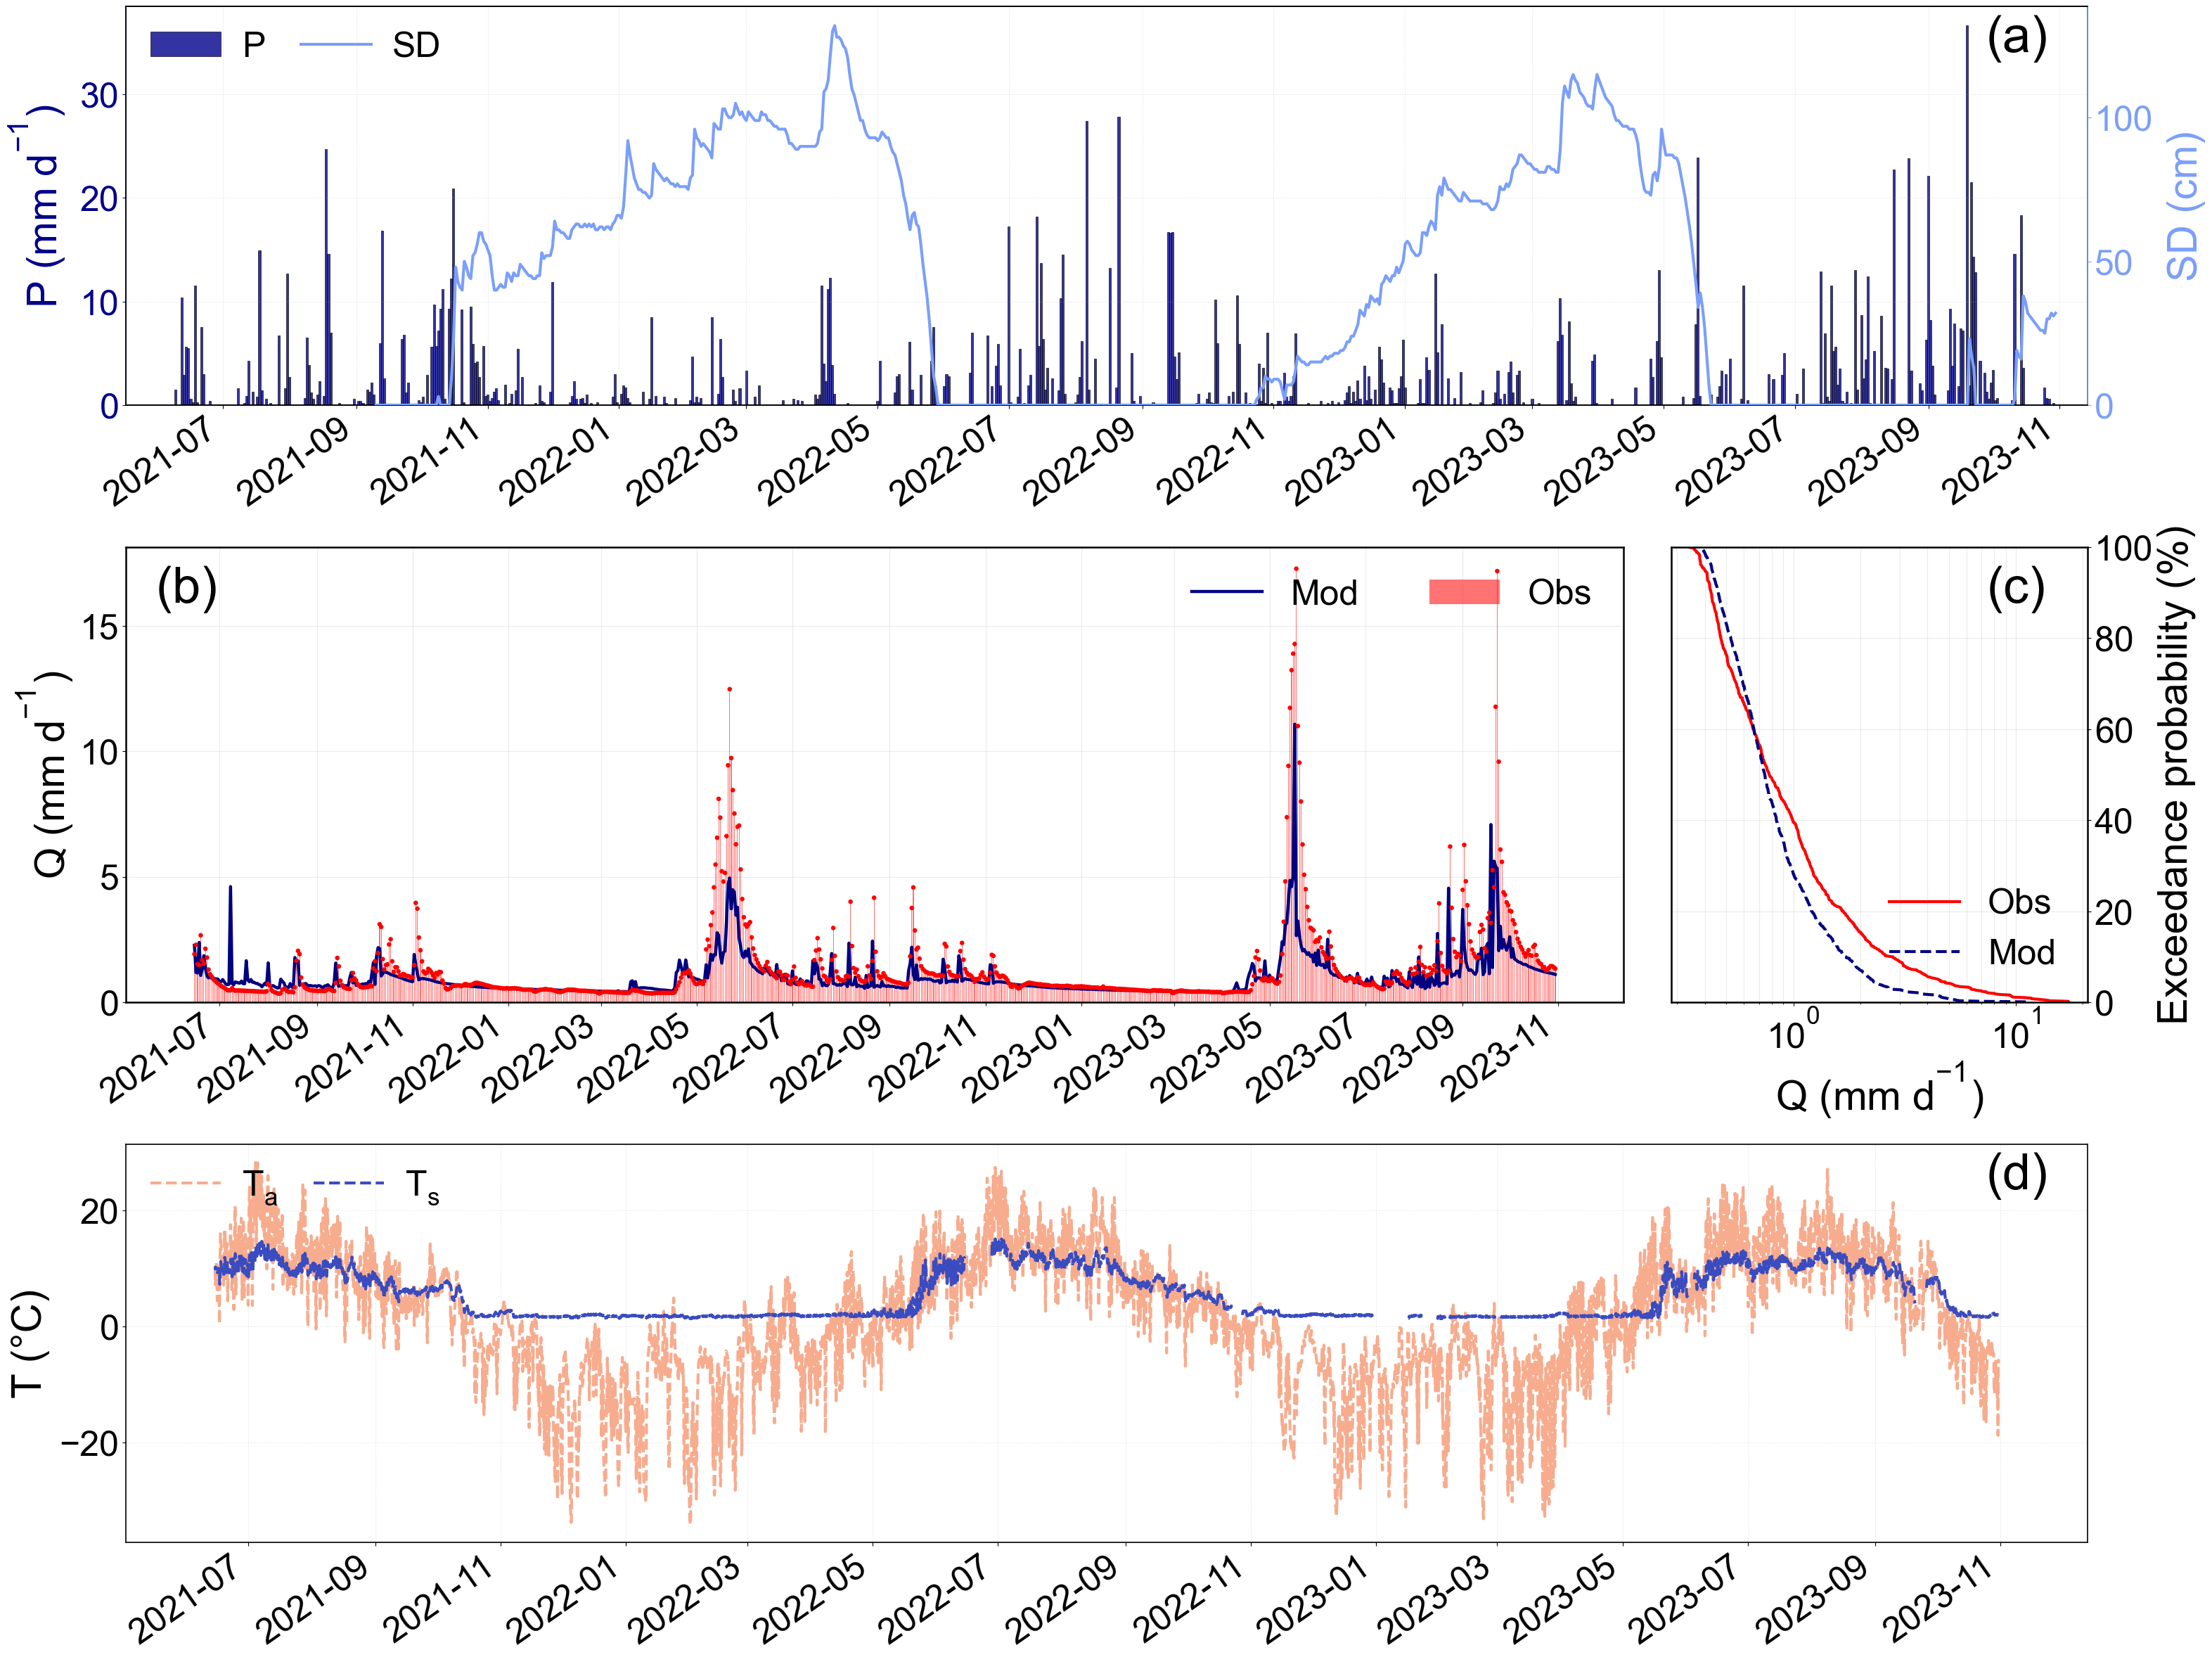

In [ ]:


import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm


BASE_DATA_DIR = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Dataset - All"

# FMI DAILY P CSV (use this for panel a)
FMI_P_DAILY_CSV = r"C:\Users\pparvizi24\Downloads\Kittilä Lompolonvuoma_ 1.1.2021 - 31.12.2025_dfab6f7d-a965-454e-ab03-97157024fa4c.csv"

# Model forcing still used by the model (not for plotting P anymore)
FORCING_CSV = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Input\spafhy_input\pallas\forcing\FORCING.csv"

RUNOFF_FILE  = rf"{BASE_DATA_DIR}\Discharge - CSV\30 min interval Discharge\30 min interval Discharge.New csv file.csv"
SNOW_FILE    = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Input\spafhy_input\forcing\NEW forcings 2021-2024\Snow Depth - Kittilä Kenttärova.csv"
METEO_FILE2  = rf"{BASE_DATA_DIR}\AIR - CSV - FIN\Kittilä Lompolonvuoma_ 15.6.2021 - 30.9.2024_5e96c0a2-f753-48fd-a243-b964825ff831.csv"
WATERTEMP_NC = rf"{BASE_DATA_DIR}\pallas_dts_data_f_6.nc"

MODEL_OUTPUT = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Input\spafhy_input\pallas\results\pallas_analysis_2_2D_202602181223\202602181222_inflow_to_ditch_pos.nc"

# Time window
START_DATE = "2021-06-01"
END_DATE   = "2023-10-30"
TIME_SLICE = slice(START_DATE, END_DATE)

# If you want to save:
SAVE_FIG = None  # e.g., r"C:\...\climate_Q_T_4panel.png"

plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.linewidth"] = 1.2

plt.rcParams["axes.labelsize"] = 42
plt.rcParams["xtick.labelsize"] = 36
plt.rcParams["ytick.labelsize"] = 36
plt.rcParams["legend.fontsize"] = 36

plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Arial"


coolwarm_r = cm.get_cmap("coolwarm_r")
coolwarm   = cm.get_cmap("coolwarm")

precip_color = "darkblue"
sd_color     = coolwarm_r(0.8)

air_color    = coolwarm(0.7)
water_color  = coolwarm(0.0)

OBS_COLOR = "red"
SIM_COLOR = "navy"


def read_precip_from_fmi_daily_csv(fmi_daily_csv_path, time_slice):
    """
    Reads DAILY precipitation from FMI export like:
    "Observation station","Year","Month","Day","Time [Local time]","Precipitation amount [mm]"

    Notes:
    - The FMI daily export can show time like 02:00 local time. We ignore the time and use the date.
    - -1 (or any negative) is treated as missing -> 0 for plotting.
    """
    df = pd.read_csv(fmi_daily_csv_path)
    df.columns = df.columns.str.strip()

    needed = {"Year", "Month", "Day", "Precipitation amount [mm]"}
    if not needed.issubset(set(df.columns)):
        raise ValueError(f"Missing required columns. Found: {df.columns.tolist()}")

    # Build date index (ignore the time column)
    df["time"] = pd.to_datetime(
        df["Year"].astype(str) + "-" +
        df["Month"].astype(str) + "-" +
        df["Day"].astype(str),
        errors="coerce"
    )
    df = df.dropna(subset=["time"]).set_index("time").sort_index()
    df.index = df.index.normalize()

    P = pd.to_numeric(df["Precipitation amount [mm]"], errors="coerce")

    # FMI missing flag is often -1
    P = P.where(P >= 0, np.nan)

    # For plotting, treat missing as 0
    P = P.fillna(0.0)

    return P.loc[time_slice]


def read_runoff_csv(file_path):
    df = pd.read_csv(file_path, parse_dates=["datetime"]).set_index("datetime").sort_index()
    df = df.rename(columns={"Discharge": "Q_m3s"})
    df["Q_m3s"] = pd.to_numeric(df["Q_m3s"], errors="coerce")
    return df


def read_snow_csv(file_path):
    df = pd.read_csv(file_path, encoding="utf-8-sig")
    df.columns = df.columns.str.strip()
    df["datetime"] = pd.to_datetime(
        df["Year"].astype(str)
        + "-"
        + df["Month"].astype(str)
        + "-"
        + df["Day"].astype(str)
        + " "
        + df["Time [Local time]"],
        errors="coerce"
    )
    df["Snow depth [cm]"] = pd.to_numeric(df["Snow depth [cm]"], errors="coerce").clip(lower=0)
    df["Snow depth [mm]"] = df["Snow depth [cm]"] * 10.0
    return df.dropna(subset=["datetime"]).set_index("datetime")[["Snow depth [mm]"]].resample("H").mean()


def read_airtemp_csv_fmi(file_path):
    df = pd.read_csv(file_path)
    df["datetime"] = pd.to_datetime(
        df["Vuosi"].astype(str)
        + "-"
        + df["Kuukausi"].astype(str)
        + "-"
        + df["Päivä"].astype(str)
        + " "
        + df["Aika [Paikallinen aika]"],
        errors="coerce"
    )
    df["Ilman lämpötila [°C]"] = pd.to_numeric(df["Ilman lämpötila [°C]"], errors="coerce")
    return df.dropna(subset=["datetime"]).set_index("datetime")["Ilman lämpötila [°C]"].resample("H").mean()


def compute_fdc_exceedance_percent(q_series):
    q = np.asarray(q_series, dtype=float)
    q = q[np.isfinite(q)]
    q = q[q >= 0]
    q_sorted = np.sort(q)[::-1]
    n = len(q_sorted)
    if n == 0:
        return np.array([]), np.array([])
    m = np.arange(1, n + 1)
    p_exc = 100.0 * m / (n + 1.0)
    return p_exc, q_sorted


def thicken_spines(ax, lw=1.8):
    for s in ax.spines.values():
        s.set_linewidth(lw)


def plot_all_four_panels(
    fmi_p_daily_csv,
    runoff_file,
    snow_file,
    meteo_file2,
    watertemp_file,
    model_output_nc,
    time_slice,
    start_date,
    end_date,
    save_fp=None,
):

    # P from FMI daily CSV (NOT from model forcing)
    P = read_precip_from_fmi_daily_csv(fmi_p_daily_csv, time_slice=time_slice)

    snow = read_snow_csv(snow_file).loc[time_slice]
    SD_cm = (snow["Snow depth [mm]"] * 0.1).dropna()

    Ta = read_airtemp_csv_fmi(meteo_file2).loc[start_date:end_date]

    dsT = xr.open_dataset(watertemp_file, engine="netcdf4")
    temp_var = [v for v in dsT.data_vars if "time" in dsT[v].dims][0]
    Ts = dsT[temp_var].to_pandas()
    if isinstance(Ts, pd.DataFrame):
        Ts = Ts.mean(axis=1)
    Ts = Ts.resample("H").mean().loc[start_date:end_date]


    # LOAD Q OBS + MODEL
 
    q_obs_30min = read_runoff_csv(runoff_file)
    q_obs_daily_m3s = q_obs_30min["Q_m3s"].resample("D").mean().dropna()
    q_obs_daily_m3s.index = pd.to_datetime(q_obs_daily_m3s.index).normalize()

    dsQ = xr.open_dataset(model_output_nc, engine="netcdf4")
    t_ds = pd.to_datetime(dsQ["time"].values).normalize()

    # NOTE: Your area method is still the same (may be a source of bias)
    CELLSIZE = 16
    spatial_dims = [d for d in dsQ["bucket_surface_runoff"].dims if d != "time"]
    cmask_bool = xr.apply_ufunc(np.isfinite, dsQ["bucket_surface_runoff"].isel(time=0))
    n_cells = int(cmask_bool.sum().values)
    A_m2 = n_cells * CELLSIZE * CELLSIZE

    Qsim_xr = (dsQ["bucket_surface_runoff"] + dsQ["inflow_to_ditch"]).where(cmask_bool).mean(dim=spatial_dims)
    Qsim_mm_d = pd.Series(Qsim_xr.values, index=t_ds, name="Qsim_mm_d")

    Qobs_mm_d = (q_obs_daily_m3s * 86400.0 * 1000.0 / A_m2).rename("Qobs_mm_d")

    common = Qobs_mm_d.index.intersection(Qsim_mm_d.index)
    dfQ = pd.concat([Qobs_mm_d.loc[common], Qsim_mm_d.loc[common]], axis=1).dropna()
    dfQ = dfQ.loc[pd.to_datetime(start_date):pd.to_datetime(end_date)].copy()

    pobs, qobs_sorted = compute_fdc_exceedance_percent(dfQ["Qobs_mm_d"])
    psim, qsim_sorted = compute_fdc_exceedance_percent(dfQ["Qsim_mm_d"])


    # X tick formatting

    x_locator = mdates.MonthLocator(interval=2)
    x_formatter = mdates.DateFormatter("%Y-%m")
    x_rotation = 35
    x_ha = "right"

   
    fig = plt.figure(figsize=(36, 28))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.05, 1.20, 1.05], hspace=0.34)
    PANEL_FS = 52


    ax1 = fig.add_subplot(gs[0])      # LEFT axis (P)
    ax1b = ax1.twinx()                # RIGHT axis (SD)
    ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.30)

    # P bars
    b_p = ax1.bar(
        P.index, P.values,
        width=1,
        color=precip_color, alpha=0.80,
        edgecolor="black", linewidth=0.55,
        label="P (mm d$^{-1}$)",
        zorder=1
    )

    # SD line
    l_sd, = ax1b.plot(
        SD_cm.index, SD_cm.values,
        color=sd_color, linewidth=3.0, label="SD (cm)", zorder=3
    )

    ax1.set_ylabel("P (mm d$^{-1}$)", color=precip_color, labelpad=12)
    ax1b.set_ylabel("SD (cm)", color=sd_color, labelpad=14)

    if len(SD_cm) > 0:
        ax1b.set_ylim(0, float(SD_cm.max()) * 1.05)

    ax1.yaxis.label.set_color(precip_color)
    ax1.spines["left"].set_color(precip_color)
    ax1.tick_params(axis="y", colors=precip_color)

    ax1b.yaxis.label.set_color(sd_color)
    ax1b.spines["right"].set_color(sd_color)
    ax1b.tick_params(axis="y", colors=sd_color)

    ax1.text(0.98, 0.98, "(a)", ha="right", va="top",
             transform=ax1.transAxes, fontsize=PANEL_FS)

    ax1.set_xlim(P.index.min() - pd.Timedelta(days=15),
                 P.index.max() + pd.Timedelta(days=15))

    ax1.xaxis.set_major_locator(x_locator)
    ax1.xaxis.set_major_formatter(x_formatter)
    ax1.tick_params(axis="x", rotation=x_rotation)
    for lbl in ax1.get_xticklabels():
        lbl.set_ha(x_ha)

    ax1.legend([b_p, l_sd], ["P", "SD"],
               frameon=False, loc="upper left", ncol=2,
               columnspacing=1.0, handletextpad=0.6, borderaxespad=0.3)


    gs2 = gs[1].subgridspec(1, 2, width_ratios=[3.6, 1.0], wspace=0.05)

    ax2 = fig.add_subplot(gs2[0])
    thicken_spines(ax2, lw=1.8)
    ax2.grid(True, alpha=0.25)

    ax2.bar(dfQ.index, dfQ["Qobs_mm_d"].values, width=0.5,
            color=OBS_COLOR, alpha=0.55, label="Obs", linewidth=0, zorder=2)

    ax2.scatter(dfQ.index, dfQ["Qobs_mm_d"].values,
                s=22, color=OBS_COLOR, edgecolors="none", zorder=5, label="_nolegend_")

    ax2.plot(dfQ.index, dfQ["Qsim_mm_d"].values,
             color=SIM_COLOR, linewidth=3.2, label="Mod", zorder=4)

    ax2.set_ylabel("Q (mm d$^{-1}$)")
    ax2.text(0.02, 0.96, "(b)", transform=ax2.transAxes,
             fontsize=PANEL_FS, va="top", ha="left")

    ax2.xaxis.set_major_locator(x_locator)
    ax2.xaxis.set_major_formatter(x_formatter)
    ax2.tick_params(axis="x", rotation=x_rotation)
    for lbl in ax2.get_xticklabels():
        lbl.set_ha(x_ha)

    ax2.legend(frameon=False, loc="upper right", ncol=2)

    ax3 = fig.add_subplot(gs2[1])
    thicken_spines(ax3, lw=1.8)
    ax3.grid(True, which="both", alpha=0.25)

    ax3.plot(qobs_sorted, pobs, color=OBS_COLOR, linewidth=3.0, label="Obs")
    ax3.plot(qsim_sorted, psim, color=SIM_COLOR, linewidth=3.0, linestyle="--", label="Mod")

    ax3.set_xscale("log")
    ax3.set_xlabel("Q (mm d$^{-1}$)")
    ax3.set_ylabel("Exceedance probability (%)")
    ax3.yaxis.set_label_position("right")
    ax3.yaxis.tick_right()
    ax3.set_ylim(0, 100)
    ax3.set_yticks(np.arange(0, 101, 20))

    ax3.text(0.90, 0.96, "(c)", transform=ax3.transAxes,
             fontsize=PANEL_FS, va="top", ha="right")

    ax3.legend(frameon=False, loc="lower right")

 
    ax4 = fig.add_subplot(gs[2])
    ax4.grid(True, linestyle="--", linewidth=0.5, alpha=0.30)

    ax4.plot(Ta.index, Ta.values, color=air_color, linestyle="--", linewidth=3.0, label="$T_a$")
    ax4.plot(Ts.index, Ts.values, color=water_color, linestyle="--", linewidth=3.0, label="$T_s$")

    ax4.set_ylabel("T (°C)", labelpad=10)

    ax4.text(0.98, 0.98, "(d)", ha="right", va="top",
             transform=ax4.transAxes, fontsize=PANEL_FS)

    ax4.xaxis.set_major_locator(x_locator)
    ax4.xaxis.set_major_formatter(x_formatter)
    ax4.tick_params(axis="x", rotation=x_rotation)
    for lbl in ax4.get_xticklabels():
        lbl.set_ha(x_ha)

    ax4.legend(frameon=False, loc="upper left",
               ncol=2, columnspacing=1.0, handletextpad=0.6, borderaxespad=0.3)

    plt.subplots_adjust(bottom=0.10)

    if save_fp:
        plt.savefig(save_fp, dpi=300, bbox_inches="tight")
    plt.show()


plot_all_four_panels(
    fmi_p_daily_csv=FMI_P_DAILY_CSV,
    runoff_file=RUNOFF_FILE,
    snow_file=SNOW_FILE,
    meteo_file2=METEO_FILE2,
    watertemp_file=WATERTEMP_NC,
    model_output_nc=MODEL_OUTPUT,
    time_slice=TIME_SLICE,
    start_date=START_DATE,
    end_date=END_DATE,
    save_fp=SAVE_FIG
)

In [ ]:


import numpy as np
import pandas as pd
import xarray as xr

=
BASE_DATA_DIR = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Dataset - All"

FMI_P_DAILY_CSV = r"C:\Users\pparvizi24\Downloads\Kittilä Lompolonvuoma_ 1.1.2021 - 31.12.2025_dfab6f7d-a965-454e-ab03-97157024fa4c.csv"
RUNOFF_FILE  = rf"{BASE_DATA_DIR}\Discharge - CSV\30 min interval Discharge\30 min interval Discharge.New csv file.csv"
MODEL_OUTPUT = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Input\spafhy_input\pallas\results\pallas_analysis_2_2D_202602181223\202602181222_inflow_to_ditch_pos.nc"

# Years to analyze
YEARS = [2021, 2022, 2023]

# Cells / area assumptions 
CELLSIZE = 16  
MODEL_RUNOFF_VAR = "bucket_surface_runoff"
MODEL_DITCH_VAR  = "inflow_to_ditch"

def read_precip_from_fmi_daily_csv(fmi_daily_csv_path):
    """
    Reads DAILY precipitation from FMI export like:
    "Observation station","Year","Month","Day","Time [Local time]","Precipitation amount [mm]"

    - Ignores time and uses date.
    - Negative values treated as missing -> NaN, then filled with 0.0.
    """
    df = pd.read_csv(fmi_daily_csv_path)
    df.columns = df.columns.str.strip()

    needed = {"Year", "Month", "Day", "Precipitation amount [mm]"}
    if not needed.issubset(set(df.columns)):
        raise ValueError(f"Missing required columns. Found: {df.columns.tolist()}")

    df["date"] = pd.to_datetime(
        df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-" + df["Day"].astype(str),
        errors="coerce"
    )
    df = df.dropna(subset=["date"]).set_index("date").sort_index()
    df.index = df.index.normalize()

    P = pd.to_numeric(df["Precipitation amount [mm]"], errors="coerce")
    P = P.where(P >= 0, np.nan).fillna(0.0)  # missing -> 0.0
    P.name = "P_forcing_mm_d"
    return P


def read_runoff_obs_daily_mm_d(runoff_file, A_m2):
    """
    Reads 30-min discharge [m3/s] -> daily mean -> convert to mm/d using catchment area A_m2.
    """
    df = pd.read_csv(runoff_file, parse_dates=["datetime"]).set_index("datetime").sort_index()
    df = df.rename(columns={"Discharge": "Q_m3s"})
    df["Q_m3s"] = pd.to_numeric(df["Q_m3s"], errors="coerce")

    q_daily_m3s = df["Q_m3s"].resample("D").mean().dropna()
    q_daily_m3s.index = q_daily_m3s.index.normalize()

    Qobs_mm_d = (q_daily_m3s * 86400.0 * 1000.0 / A_m2).rename("Qobs_mm_d")
    return Qobs_mm_d


def read_qsim_daily_mm_d(model_output_nc):
    """
    Reads model runoff + inflow_to_ditch -> area-average (mm/d).
    Also returns mask_bool, n_cells, and time index.
    """
    dsQ = xr.open_dataset(model_output_nc, engine="netcdf4")

    if MODEL_RUNOFF_VAR not in dsQ.variables:
        raise KeyError(f"Variable '{MODEL_RUNOFF_VAR}' not found in model output.")
    if MODEL_DITCH_VAR not in dsQ.variables:
        raise KeyError(f"Variable '{MODEL_DITCH_VAR}' not found in model output.")

    t_ds = pd.to_datetime(dsQ["time"].values).normalize()

    spatial_dims = [d for d in dsQ[MODEL_RUNOFF_VAR].dims if d != "time"]
    cmask_bool = xr.apply_ufunc(np.isfinite, dsQ[MODEL_RUNOFF_VAR].isel(time=0))
    n_cells = int(cmask_bool.sum().values)
    A_m2 = n_cells * CELLSIZE * CELLSIZE

    Qsim_xr = (dsQ[MODEL_RUNOFF_VAR] + dsQ[MODEL_DITCH_VAR]).where(cmask_bool).mean(dim=spatial_dims)
    Qsim_mm_d = pd.Series(Qsim_xr.values, index=t_ds, name="Qsim_mm_d")

    dsQ.close()
    return Qsim_mm_d, A_m2, n_cells


def window_df(df, center_date, days_before, days_after):
    """
    Return df in [center_date-days_before, center_date+days_after]
    """
    start = center_date - pd.Timedelta(days=days_before)
    end   = center_date + pd.Timedelta(days=days_after)
    return df.loc[start:end]


def safe_pick_max(series):
    series = series.dropna()
    if series.empty:
        return None, None
    idx = series.idxmax()
    val = float(series.loc[idx])
    return idx, val


P_daily = read_precip_from_fmi_daily_csv(FMI_P_DAILY_CSV)

Qsim_mm_d, A_m2, n_cells = read_qsim_daily_mm_d(MODEL_OUTPUT)
Qobs_mm_d = read_runoff_obs_daily_mm_d(RUNOFF_FILE, A_m2=A_m2)

common = P_daily.index.intersection(Qobs_mm_d.index).intersection(Qsim_mm_d.index)
df = pd.concat(
    [P_daily.loc[common], Qobs_mm_d.loc[common], Qsim_mm_d.loc[common]],
    axis=1
).sort_index()

print("============================================================")
print("PEAK-P AND PEAK MAY-Q SUMMARY FOR ALL YEARS")
print(f"Years processed: {YEARS}")
print("============================================================")
print("")
print(f"Catchment area A_m2 = {A_m2:.2f} (n_cells={n_cells}, cell={CELLSIZE} m)")
print("")

for yr in YEARS:
    print("")
    print("#" * 24 + f"  YEAR {yr}  " + "#" * 24)
    dfy = df.loc[f"{yr}-01-01":f"{yr}-12-31"].copy()

    # -------------------------
    # (1) Peak P (FMI daily)
    # -------------------------
    p_date, p_max = safe_pick_max(dfy["P_forcing_mm_d"])
    if p_date is None:
        print("\nNo precipitation data for this year.")
    else:
        # Q on the peak-P day
        qobs_on_p = float(dfy.loc[p_date, "Qobs_mm_d"]) if p_date in dfy.index else np.nan
        qsim_on_p = float(dfy.loc[p_date, "Qsim_mm_d"]) if p_date in dfy.index else np.nan

        print(f"\n=== Max Daily Precipitation (FMI) ({yr}) ===")
        print(f"Date: {p_date.date()} | Pmax = {p_max:.3f} mm/d | Qobs = {qobs_on_p:.3f} mm/d | Qsim = {qsim_on_p:.3f} mm/d")

        print("\n=== ±1 Day Window Around Pmax ({}) ===".format(yr))
        winP = window_df(dfy[["P_forcing_mm_d", "Qobs_mm_d", "Qsim_mm_d"]], p_date, 1, 1)
        winP = winP.rename(columns={"P_forcing_mm_d": "P_mm_d"})
        print(winP.to_string(index=True))

    # -------------------------
    # (2) Peak Q in May (Obs)
    # -------------------------
    may = dfy.loc[f"{yr}-05-01":f"{yr}-05-31"].copy()

    q_date, q_max = safe_pick_max(may["Qobs_mm_d"])
    if q_date is None:
        print("\nNo May discharge data for this year.")
    else:
        # P and Qsim on the peak-Q day
        p_on_q = float(dfy.loc[q_date, "P_forcing_mm_d"]) if q_date in dfy.index else np.nan
        qsim_on_q = float(dfy.loc[q_date, "Qsim_mm_d"]) if q_date in dfy.index else np.nan

        print(f"\n=== Max Observed Daily Discharge in May ({yr}) ===")
        print(f"Date: {q_date.date()} | Qobs,max = {q_max:.3f} mm/d | Qsim = {qsim_on_q:.3f} mm/d | P = {p_on_q:.3f} mm/d")

        print("\n=== ±3 Day Window Around May Qobs Peak ({}) ===".format(yr))
        winQ = window_df(dfy[["P_forcing_mm_d", "Qobs_mm_d", "Qsim_mm_d"]], q_date, 3, 3)
        winQ = winQ.rename(columns={"P_forcing_mm_d": "P_mm_d"})
        print(winQ.to_string(index=True))

print("\n============================================================")
print("Done.")
print("============================================================")

PEAK-P AND PEAK MAY-Q SUMMARY FOR ALL YEARS
Years processed: [2021, 2022, 2023]

Catchment area A_m2 = 4187136.00 (n_cells=16356, cell=16 m)


########################  YEAR 2021  ########################

=== Max Daily Precipitation (FMI) (2021) ===
Date: 2021-08-18 | Pmax = 24.700 mm/d | Qobs = 0.600 mm/d | Qsim = 1.786 mm/d

=== ±1 Day Window Around Pmax (2021) ===
            P_mm_d  Qobs_mm_d  Qsim_mm_d
2021-08-17     0.9   0.399667   0.579379
2021-08-18    24.7   0.600167   1.785566
2021-08-19    14.6   1.659798   1.594112

No May discharge data for this year.

########################  YEAR 2022  ########################

=== Max Daily Precipitation (FMI) (2022) ===
Date: 2022-08-21 | Pmax = 27.800 mm/d | Qobs = 1.651 mm/d | Qsim = 2.443 mm/d

=== ±1 Day Window Around Pmax (2022) ===
            P_mm_d  Qobs_mm_d  Qsim_mm_d
2022-08-20     1.7   0.937457   0.660838
2022-08-21    27.8   1.650985   2.442696
2022-08-22     0.1   4.167507   0.601529

=== Max Observed Daily Discharge 

In [ ]:

import numpy as np
import pandas as pd
import xarray as xr


BASE_DATA_DIR = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Dataset - All"

FMI_P_DAILY_CSV = r"C:\Users\pparvizi24\Downloads\Kittilä Lompolonvuoma_ 1.1.2021 - 31.12.2025_dfab6f7d-a965-454e-ab03-97157024fa4c.csv"
RUNOFF_FILE  = rf"{BASE_DATA_DIR}\Discharge - CSV\30 min interval Discharge\30 min interval Discharge.New csv file.csv"
MODEL_OUTPUT = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Input\spafhy_input\pallas\results\pallas_analysis_2_2D_202602181223\202602181222_inflow_to_ditch_pos.nc"

# Years to analyze
YEARS = [2021, 2022, 2023]

# Cells / area assumptions (keep same as your plotting script)
CELLSIZE = 16  # m
MODEL_RUNOFF_VAR = "bucket_surface_runoff"
MODEL_DITCH_VAR  = "inflow_to_ditch"

# Months for peak-Q (observed) analysis and window size
PEAK_Q_MONTHS = [
    ("May", 5, 3),
    ("Aug", 8, 3),
    ("Oct", 10, 3),
]

def read_precip_from_fmi_daily_csv(fmi_daily_csv_path):
    df = pd.read_csv(fmi_daily_csv_path)
    df.columns = df.columns.str.strip()

    needed = {"Year", "Month", "Day", "Precipitation amount [mm]"}
    if not needed.issubset(set(df.columns)):
        raise ValueError(f"Missing required columns. Found: {df.columns.tolist()}")

    df["date"] = pd.to_datetime(
        df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-" + df["Day"].astype(str),
        errors="coerce"
    )
    df = df.dropna(subset=["date"]).set_index("date").sort_index()
    df.index = df.index.normalize()

    P = pd.to_numeric(df["Precipitation amount [mm]"], errors="coerce")
    P = P.where(P >= 0, np.nan).fillna(0.0)
    P.name = "P_forcing_mm_d"
    return P


def read_runoff_obs_daily_mm_d(runoff_file, A_m2):
    df = pd.read_csv(runoff_file, parse_dates=["datetime"]).set_index("datetime").sort_index()
    df = df.rename(columns={"Discharge": "Q_m3s"})
    df["Q_m3s"] = pd.to_numeric(df["Q_m3s"], errors="coerce")

    q_daily_m3s = df["Q_m3s"].resample("D").mean().dropna()
    q_daily_m3s.index = q_daily_m3s.index.normalize()

    Qobs_mm_d = (q_daily_m3s * 86400.0 * 1000.0 / A_m2).rename("Qobs_mm_d")
    return Qobs_mm_d


def read_qsim_daily_mm_d(model_output_nc):
    dsQ = xr.open_dataset(model_output_nc, engine="netcdf4")

    if MODEL_RUNOFF_VAR not in dsQ.variables:
        raise KeyError(f"Variable '{MODEL_RUNOFF_VAR}' not found in model output.")
    if MODEL_DITCH_VAR not in dsQ.variables:
        raise KeyError(f"Variable '{MODEL_DITCH_VAR}' not found in model output.")

    t_ds = pd.to_datetime(dsQ["time"].values).normalize()

    spatial_dims = [d for d in dsQ[MODEL_RUNOFF_VAR].dims if d != "time"]
    cmask_bool = xr.apply_ufunc(np.isfinite, dsQ[MODEL_RUNOFF_VAR].isel(time=0))
    n_cells = int(cmask_bool.sum().values)
    A_m2 = n_cells * CELLSIZE * CELLSIZE

    Qsim_xr = (dsQ[MODEL_RUNOFF_VAR] + dsQ[MODEL_DITCH_VAR]).where(cmask_bool).mean(dim=spatial_dims)
    Qsim_mm_d = pd.Series(Qsim_xr.values, index=t_ds, name="Qsim_mm_d")

    dsQ.close()
    return Qsim_mm_d, A_m2, n_cells


def window_df(df_in, center_date, days_before, days_after):
    start = center_date - pd.Timedelta(days=days_before)
    end   = center_date + pd.Timedelta(days=days_after)
    return df_in.loc[start:end]


def safe_pick_max(series):
    series = series.dropna()
    if series.empty:
        return None, None
    idx = series.idxmax()
    val = float(series.loc[idx])
    return idx, val


def month_slice(dfy, yr, month):
    start = pd.Timestamp(year=yr, month=month, day=1)
    end = (start + pd.offsets.MonthEnd(1))
    return dfy.loc[start:end].copy()


def print_peak_q_month(dfy, yr, label, month_num, win_days):
    dfm = month_slice(dfy, yr, month_num)

    q_date, q_max = safe_pick_max(dfm["Qobs_mm_d"])
    if q_date is None:
        print(f"\nNo {label} discharge data for this year.")
        return

    p_on_q = float(dfy.loc[q_date, "P_forcing_mm_d"]) if q_date in dfy.index else np.nan
    qsim_on_q = float(dfy.loc[q_date, "Qsim_mm_d"]) if q_date in dfy.index else np.nan

    print(f"\n=== Max Observed Daily Discharge in {label} ({yr}) ===")
    print(
        f"Date: {q_date.date()} | "
        f"Qobs,max = {q_max:.3f} mm/d | "
        f"Qsim = {qsim_on_q:.3f} mm/d | "
        f"P = {p_on_q:.3f} mm/d"
    )

    print(f"\n=== ±{win_days} Day Window Around {label} Qobs Peak ({yr}) ===")
    winQ = window_df(dfy[["P_forcing_mm_d", "Qobs_mm_d", "Qsim_mm_d"]], q_date, win_days, win_days)
    winQ = winQ.rename(columns={"P_forcing_mm_d": "P_mm_d"})
    print(winQ.to_string(index=True))



# BUILD DAILY DATAFRAME: P, Qobs, Qsim (common dates)

P_daily = read_precip_from_fmi_daily_csv(FMI_P_DAILY_CSV)

Qsim_mm_d, A_m2, n_cells = read_qsim_daily_mm_d(MODEL_OUTPUT)
Qobs_mm_d = read_runoff_obs_daily_mm_d(RUNOFF_FILE, A_m2=A_m2)

common = P_daily.index.intersection(Qobs_mm_d.index).intersection(Qsim_mm_d.index)
df = pd.concat([P_daily.loc[common], Qobs_mm_d.loc[common], Qsim_mm_d.loc[common]], axis=1).sort_index()

print("============================================================")
print("PEAK-P AND PEAK Q (MAY, AUG, OCT) SUMMARY FOR ALL YEARS")
print(f"Years processed: {YEARS}")
print("============================================================\n")
print(f"Catchment area A_m2 = {A_m2:.2f} (n_cells={n_cells}, cell={CELLSIZE} m)\n")

for yr in YEARS:
    print("\n" + "#" * 24 + f"  YEAR {yr}  " + "#" * 24)
    dfy = df.loc[f"{yr}-01-01":f"{yr}-12-31"].copy()

    # -------------------------
    # (1) Peak P (FMI daily) - full year
    # -------------------------
    p_date, p_max = safe_pick_max(dfy["P_forcing_mm_d"])
    if p_date is None:
        print("\nNo precipitation data for this year.")
    else:
        qobs_on_p = float(dfy.loc[p_date, "Qobs_mm_d"]) if p_date in dfy.index else np.nan
        qsim_on_p = float(dfy.loc[p_date, "Qsim_mm_d"]) if p_date in dfy.index else np.nan

        print(f"\n=== Max Daily Precipitation (FMI) ({yr}) ===")
        print(
            f"Date: {p_date.date()} | "
            f"Pmax = {p_max:.3f} mm/d | "
            f"Qobs = {qobs_on_p:.3f} mm/d | "
            f"Qsim = {qsim_on_p:.3f} mm/d"
        )

        print(f"\n=== ±1 Day Window Around Pmax ({yr}) ===")
        winP = window_df(dfy[["P_forcing_mm_d", "Qobs_mm_d", "Qsim_mm_d"]], p_date, 1, 1)
        winP = winP.rename(columns={"P_forcing_mm_d": "P_mm_d"})
        print(winP.to_string(index=True))

    # -------------------------
    # (2) Peak Qobs by month: May, Aug, Oct
    # -------------------------
    for label, month_num, win_days in PEAK_Q_MONTHS:
        print_peak_q_month(dfy, yr, label, month_num, win_days)

print("\n============================================================")
print("Done.")
print("============================================================")

PEAK-P AND PEAK Q (MAY, AUG, OCT) SUMMARY FOR ALL YEARS
Years processed: [2021, 2022, 2023]

Catchment area A_m2 = 4187136.00 (n_cells=16356, cell=16 m)


########################  YEAR 2021  ########################

=== Max Daily Precipitation (FMI) (2021) ===
Date: 2021-08-18 | Pmax = 24.700 mm/d | Qobs = 0.600 mm/d | Qsim = 1.786 mm/d

=== ±1 Day Window Around Pmax (2021) ===
            P_mm_d  Qobs_mm_d  Qsim_mm_d
2021-08-17     0.9   0.399667   0.579379
2021-08-18    24.7   0.600167   1.785566
2021-08-19    14.6   1.659798   1.594112

No May discharge data for this year.

=== Max Observed Daily Discharge in Aug (2021) ===
Date: 2021-08-20 | Qobs,max = 2.053 mm/d | Qsim = 1.654 mm/d | P = 7.000 mm/d

=== ±3 Day Window Around Aug Qobs Peak (2021) ===
            P_mm_d  Qobs_mm_d  Qsim_mm_d
2021-08-17     0.9   0.399667   0.579379
2021-08-18    24.7   0.600167   1.785566
2021-08-19    14.6   1.659798   1.594112
2021-08-20     7.0   2.052888   1.653674
2021-08-21     0.0   1.922202

In [ ]:


yr = 2023
dfy = df.loc[f"{yr}-01-01":f"{yr}-12-31"].copy()

top = dfy.sort_values("Qobs_mm_d", ascending=False).head(10)[["P_forcing_mm_d","Qobs_mm_d","Qsim_mm_d"]]
top = top.rename(columns={"P_forcing_mm_d":"P_mm_d"})

print("\nTOP 10 Qobs days in 2023 (exact dates):")
print(top.to_string())


TOP 10 Qobs days in 2023 (exact dates):
            P_mm_d  Qobs_mm_d  Qsim_mm_d
2023-05-18     0.9  17.276430   2.659126
2023-09-23    12.8  17.181295   5.330820
2023-05-17    23.9  14.278519  11.082784
2023-05-16     7.8  13.891533   5.017802
2023-05-15     0.7  13.234836   4.606646
2023-09-22    14.3  11.777000   5.419387
2023-05-14     0.0  11.731303   4.860131
2023-05-19     0.0  11.008102   3.240979
2023-09-24     0.0   9.588139   2.059694
2023-05-20     0.0   9.549578   2.673271


In [ ]:
yr = 2023
dfy = df.loc[f"{yr}-01-01":f"{yr}-12-31"].copy()

top = dfy.sort_values("Qobs_mm_d", ascending=False).head(12)[
    ["P_forcing_mm_d", "Qobs_mm_d", "Qsim_mm_d"]
].rename(columns={"P_forcing_mm_d": "P_mm_d"})

print(top.to_string())


sep23 = dfy.loc["2023-09-01":"2023-09-30"].copy()

print("\nSEP 2023 summary:")
print(sep23[["Qobs_mm_d", "Qsim_mm_d"]].describe())

print("\nTop 10 Qobs days in Sep 2023:")
print(sep23.sort_values("Qobs_mm_d", ascending=False).head(10).to_string())

print("\nAny Sep 2023 days with Qobs > 10 mm/d?")
print(sep23[sep23["Qobs_mm_d"] > 10][["Qobs_mm_d", "Qsim_mm_d"]].to_string())

            P_mm_d  Qobs_mm_d  Qsim_mm_d
2023-05-18     0.9  17.276430   2.659126
2023-09-23    12.8  17.181295   5.330820
2023-05-17    23.9  14.278519  11.082784
2023-05-16     7.8  13.891533   5.017802
2023-05-15     0.7  13.234836   4.606646
2023-09-22    14.3  11.777000   5.419387
2023-05-14     0.0  11.731303   4.860131
2023-05-19     0.0  11.008102   3.240979
2023-09-24     0.0   9.588139   2.059694
2023-05-20     0.0   9.549578   2.673271
2023-05-13     0.0   9.421213   4.036855
2023-05-21     0.0   8.002969   2.282139

SEP 2023 summary:
       Qobs_mm_d  Qsim_mm_d
count  30.000000  30.000000
mean    4.469780   2.381263
std     3.279024   1.539538
min     1.762584   1.104389
25%     2.523314   1.279568
50%     3.720961   2.069048
75%     4.764966   2.336654
max    17.181295   7.084700

Top 10 Qobs days in Sep 2023:
            P_forcing_mm_d  Qobs_mm_d  Qsim_mm_d
2023-09-23            12.8  17.181295   5.330820
2023-09-22            14.3  11.777000   5.419387
2023-09-24        

In [7]:
import xarray as xr
import pandas as pd

NC_PATH = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Input\spafhy_input\pallas\results\pallas_analysis_2_2D_202602181223\202602181222_inflow_to_ditch_pos.nc"

ds = xr.open_dataset(NC_PATH, engine="netcdf4")

print("\n=== DATASET SUMMARY ===")
print(ds)

print("\n=== DIMS ===")
print(ds.dims)

print("\n=== COORDS ===")
print(list(ds.coords))

print("\n=== VARS ===")
print(list(ds.data_vars))

print("\n=== TIME COORD GUESS ===")
for tname in ["time", "Time", "DATE", "date", "datetime"]:
    if tname in ds.coords or tname in ds.variables:
        t = pd.to_datetime(ds[tname].values)
        print(f"{tname}: {t.min()} -> {t.max()} (n={len(t)})")
        break

print("\n=== UNITS (first 30 vars that have units) ===")
n = 0
for v in list(ds.data_vars):
    u = ds[v].attrs.get("units", None)
    if u is not None:
        print(f"{v}: units={u}")
        n += 1
    if n >= 30:
        break


=== DATASET SUMMARY ===
<xarray.Dataset> Size: 6GB
Dimensions:                         (time: 1826, lat: 221, lon: 136)
Coordinates:
  * time                            (time) datetime64[ns] 15kB 2019-01-01 ......
  * lat                             (lat) float64 2kB 7.546e+06 ... 7.542e+06
  * lon                             (lon) float64 1kB 3.829e+05 ... 3.851e+05
Data variables: (12/56)
    parameters_lai_conif            (lat, lon) float32 120kB ...
    parameters_lai_decid_max        (lat, lon) float32 120kB ...
    parameters_lai_shrub            (lat, lon) float32 120kB ...
    parameters_lai_grass            (lat, lon) float32 120kB ...
    parameters_hc                   (lat, lon) float32 120kB ...
    parameters_cf                   (lat, lon) float32 120kB ...
    ...                              ...
    top_water_closure               (time) float32 7kB ...
    top_returnflow                  (time) float32 7kB ...
    top_local_returnflow            (time, lat, lon) flo

In [8]:
import pandas as pd
import numpy as np

FORCING_CSV = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Input\spafhy_input\pallas\forcing\FORCING.csv"

def read_forcing_csv(fp):
    # Main fix: semicolon separator
    df = pd.read_csv(fp, sep=";", engine="python")
    df.columns = [c.strip() for c in df.columns]

    # Parse time column
    if "time" not in df.columns:
        raise ValueError(f"'time' column not found. Columns: {df.columns.tolist()}")

    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.dropna(subset=["time"]).set_index("time").sort_index()

    # Convert all other columns to numeric where possible
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df

def print_forcing_debug(df):
    print("=== PARSED FORCING SHAPE ===")
    print(df.shape)

    print("\n=== COLUMNS ===")
    print(df.columns.tolist())

    print("\n=== TIME COVERAGE ===")
    print("Start:", df.index.min())
    print("End:  ", df.index.max())
    print("N:    ", len(df.index))

    if len(df.index) > 2:
        diffs = df.index.to_series().diff().dropna()
        print("\n=== TIME STEP (most common) ===")
        print(diffs.value_counts().head(5))

    print("\n=== HEAD (5) ===")
    print(df.head(5))

    print("\n=== TAIL (5) ===")
    print(df.tail(5))

    print("\n=== MISSING VALUES (top 20) ===")
    miss = df.isna().sum().sort_values(ascending=False)
    print(miss.head(20))

    # Rainfall checks
    if "rainfall" in df.columns:
        p = df["rainfall"]
        print("\n=== RAINFALL STATS (rainfall) ===")
        print("Min:", float(np.nanmin(p.values)))
        print("Max:", float(np.nanmax(p.values)))
        print("Mean:", float(np.nanmean(p.values)))
        print("Nonzero count:", int((p.fillna(0) > 0).sum()))

        print("\nFirst 15 nonzero rainfall days:")
        print(p[p > 0].head(15))

        print("\nTop 15 rainfall days:")
        print(p.sort_values(ascending=False).head(15))
    else:
        print("\nNo 'rainfall' column found. Closest matches:")
        print([c for c in df.columns if "rain" in c.lower() or "prec" in c.lower()])

    # Numeric summary
    num = df.select_dtypes(include=[np.number])
    print("\n=== NUMERIC SUMMARY (first 25 vars) ===")
    print(num.describe().T.head(25))

def main():
    df = read_forcing_csv(FORCING_CSV)
    print_forcing_debug(df)

if __name__ == "__main__":
    main()

=== PARSED FORCING SHAPE ===
(6246, 15)

=== COLUMNS ===
['UTC', 'ID', 'cloudiness', 'hpa', 'rh', 'rainfall', 't_mean', 't_dewpoint', 'wind_speed', 'wind_direction', 'snowdepth', 'radiation', 't_min', 't_max', 'lamposumma_v']

=== TIME COVERAGE ===
Start: 2007-08-01 00:00:00
End:   2024-09-05 00:00:00
N:     6246

=== TIME STEP (most common) ===
time
1 days    6245
Name: count, dtype: int64

=== HEAD (5) ===
            UTC   ID  cloudiness          hpa         rh  rainfall     t_mean  \
time                                                                            
2007-08-01  0.0  1.0    6.680556   995.275694  97.972222  8.209655  11.547222   
2007-08-02  0.0  1.0    5.798611  1004.116667  84.812500  1.216667  13.267361   
2007-08-03  0.0  1.0    3.763889  1012.134028  78.895833  2.633333  15.017361   
2007-08-04  0.0  1.0    6.402778  1015.856250  89.854167  0.000000  13.223611   
2007-08-05  0.0  1.0    6.520833  1012.496528  89.020833  0.200000  13.325000   

            t_dewpoi